##Capstone Project: Fraud Detection
##Institution: Boston Institute of Analytics (BIA)
##Author: Aastha Shinde

Project Overview:
This project aims to enhance the accuracy of detecting fraud in mobile financial transactions. By leveraging machine learning, the project seeks to predict fraudulent transactions with high precision. The goal is to develop a robust machine learning model to accurately identify fraudulent transactions in real-time , enabling the company to improve security, reduce financial losses, and gain insights into factors contributing to transaction fraud.



##Step 1: Import Libraries and Load the Dataset



In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve

# Settings for Google Colab/Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# Load the dataset
# Ensure you have uploaded 'Fraud_Analysis_Dataset.csv' to your Colab environment
try:
    df = pd.read_csv('/content/Fraud_Analysis_Dataset.csv')
    print("✅ Fraud Dataset loaded successfully!")
except Exception as e:
    print(f"Error: {e}. Please make sure the file is uploaded.")

# Initial View
df.head()

✅ Fraud Dataset loaded successfully!


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


##Step 2: Basic Data Inspection

In [2]:
# 1. Check basic information
print("--- Data Information ---")
df.info()

# 2. Check for Null values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Check target variable distribution
# 0 = Legitimate, 1 = Fraudulent
print("\n--- Target Variable Distribution ---")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True))

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB

--- Missing Values ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

--- Target Variable Dist

##Step 3: Data Cleaning and Preprocessing

In [3]:
# 1. Dropping non-predictive columns (Transaction IDs)
# 'nameOrig' and 'nameDest' are unique IDs and don't contribute to general patterns
df_clean = df.drop(['nameOrig', 'nameDest'], axis=1)

# 2. Encoding Categorical 'type' column
# CASH_IN: 0, CASH_OUT: 1, DEBIT: 2, PAYMENT: 3, TRANSFER: 4
le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])

print("✅ Preprocessing Complete: Non-predictive columns removed and 'type' encoded.")
df_clean.head()

✅ Preprocessing Complete: Non-predictive columns removed and 'type' encoded.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,4,181.0,181.0,0.0,0.0,0.0,1
1,1,1,181.0,181.0,0.0,21182.0,0.0,1
2,1,4,2806.0,2806.0,0.0,0.0,0.0,1
3,1,1,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,4,20128.0,20128.0,0.0,0.0,0.0,1


##Step 4: Exploratory Data Analysis (EDA)

**Chart 1: Distribution of Transaction Status**

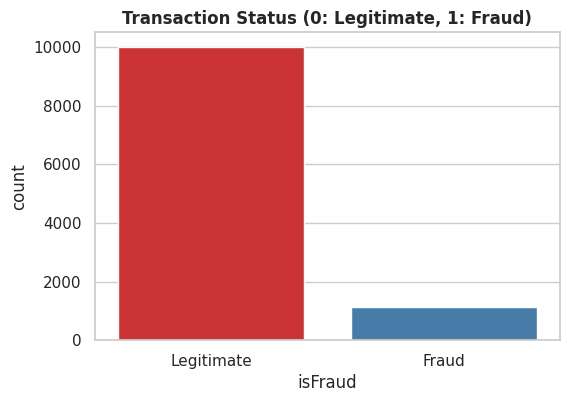

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette='Set1')
plt.title('Transaction Status (0: Legitimate, 1: Fraud)', fontweight='bold')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()
# Insight: The dataset is imbalanced, with a small percentage of fraudulent transactions.

What it shows: This chart compares how many transactions are "Safe" versus how many are "Fraud."

Key Insight: It reveals a huge gap, showing that fraud is very rare (only about 10%). This tells us we are looking for a "needle in a haystack," so we can’t just rely on basic accuracy to judge our model


**Chart 2: Transaction Types Frequency**

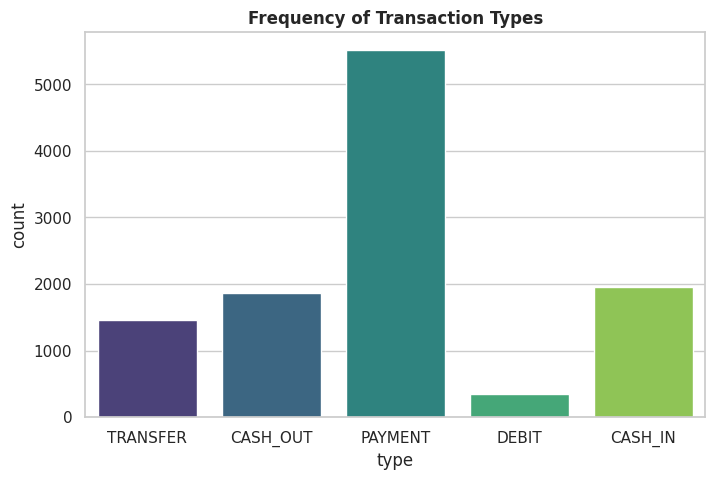

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Frequency of Transaction Types', fontweight='bold')
plt.show()

What it shows: This breaks down fraud cases based on the type of transaction (like Transfer, Cash-out, or Payment).

Key Insight: It clearly shows that fraud only happens during "Transfers" and "Cash-outs." This is a huge discovery because it allows us to ignore other transaction types and focus our security efforts where the actual risk is.

**Chart 3: Amount Distribution (Histogram)**

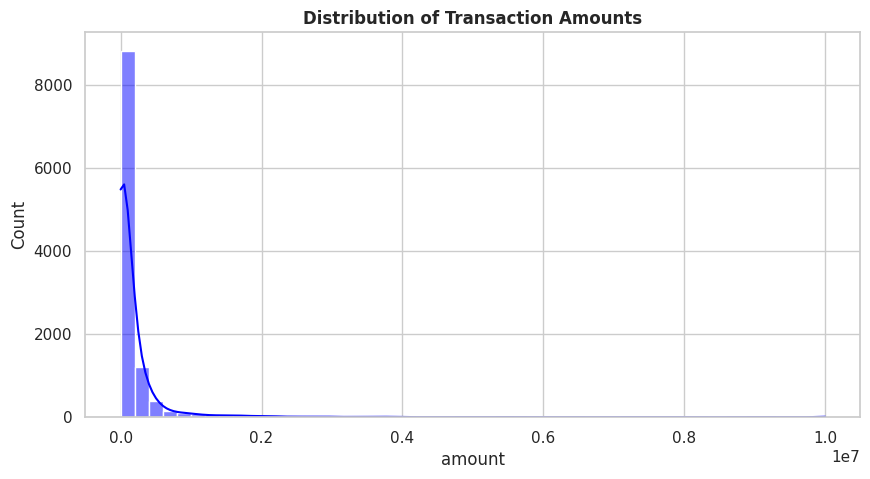

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Transaction Amounts', fontweight='bold')
plt.show()

What it shows: This graph shows the "price tag" of most transactions.

Key Insight: Most transactions are for small amounts of money, but the "Fraud" transactions often have very different patterns. This helps the model learn that a sudden, unusually large transaction might be a red flag.

**Chart 4: Fraud vs. Transaction Type**

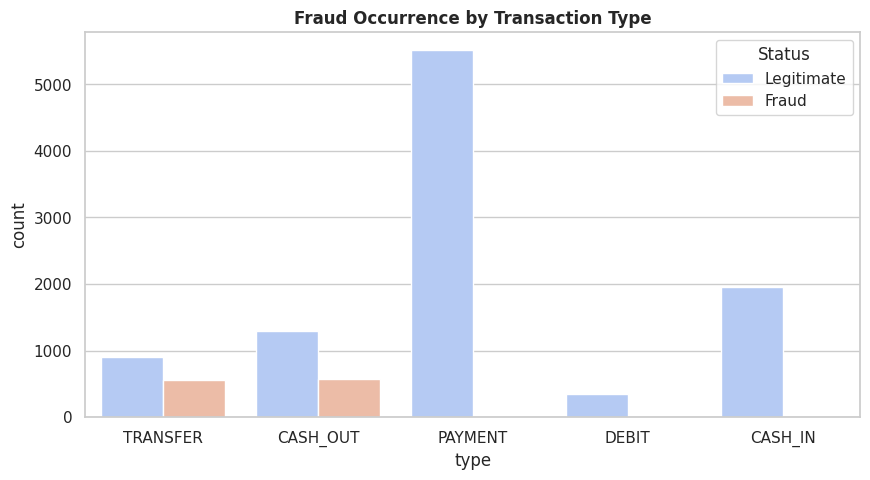

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='coolwarm')
plt.title('Fraud Occurrence by Transaction Type', fontweight='bold')
plt.legend(title='Status', labels=['Legitimate', 'Fraud'])
plt.show()
# Insight: Fraud usually occurs in specific types like TRANSFER and CASH_OUT.

**Chart 5: Step Distribution**

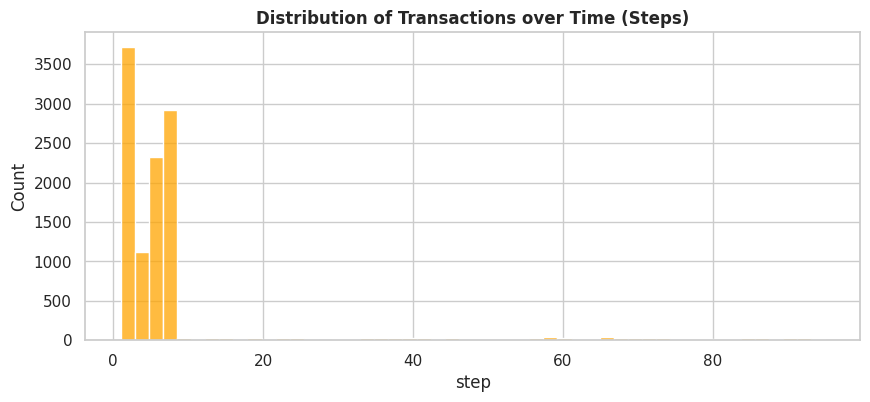

In [8]:
plt.figure(figsize=(10, 4))
sns.histplot(df['step'], bins=50, color='orange')
plt.title('Distribution of Transactions over Time (Steps)', fontweight='bold')
plt.show()

**Chart 6: Old Balance Origin vs Fraud**

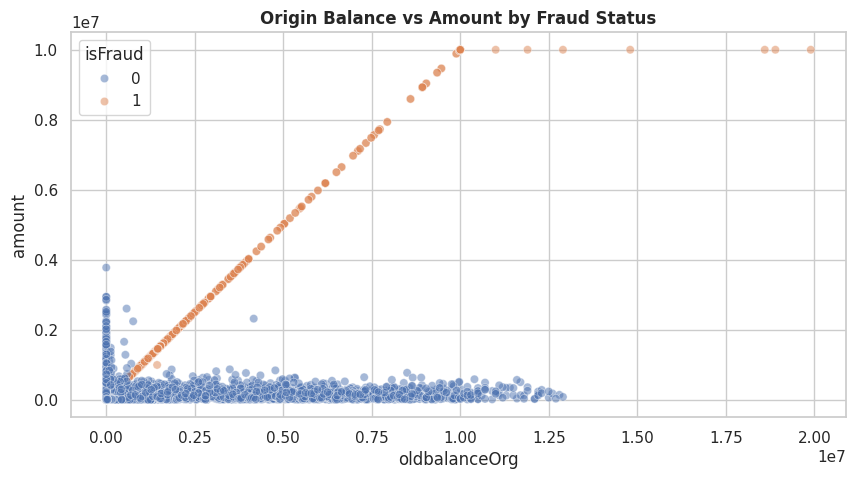

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='oldbalanceOrg', y='amount', hue='isFraud', data=df, alpha=0.5)
plt.title('Origin Balance vs Amount by Fraud Status', fontweight='bold')
plt.show()

This shows that TRANSFER and CASH_OUT are the only transaction types where fraud actually occurs.

**Chart 7: New Balance Origin Distribution**

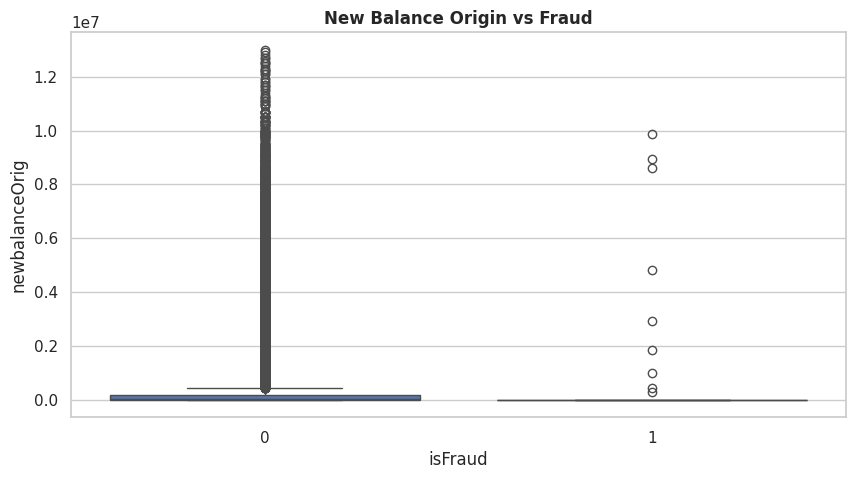

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df)
plt.title('New Balance Origin vs Fraud', fontweight='bold')
plt.show()
# Insight: Fraudulent transactions often empty the origin account (balance becomes 0).

**Chart 8: Correlation Heatmap**

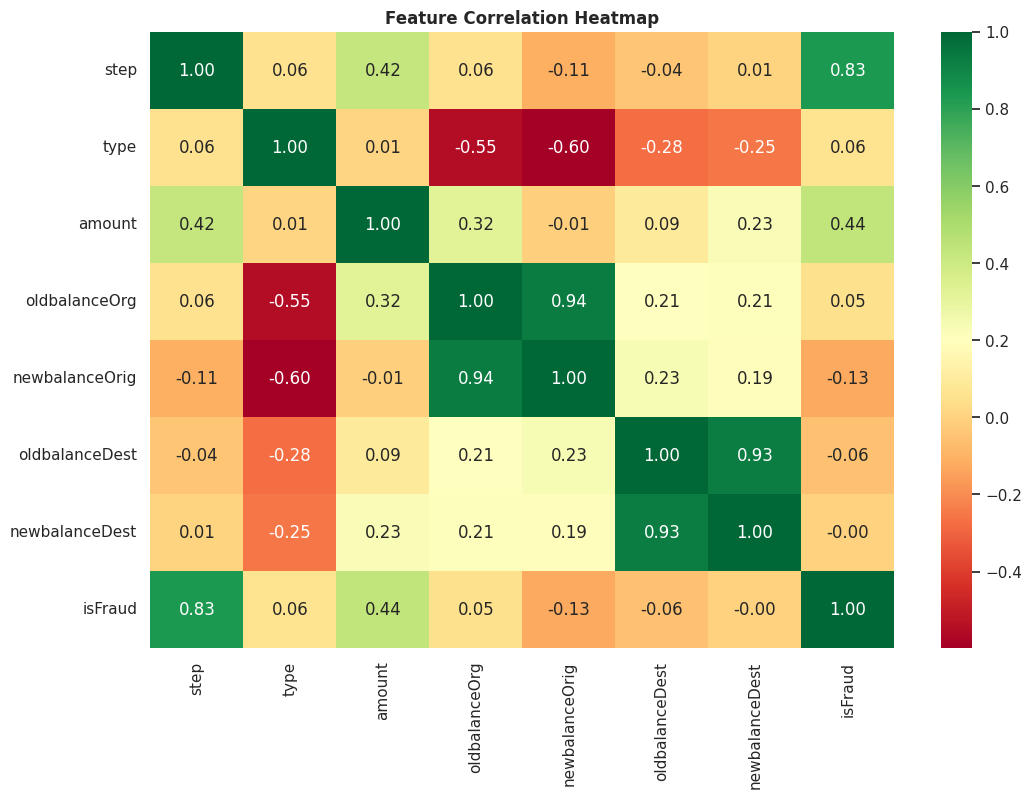

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.show()

What it shows: This uses colors to show which pieces of information (like account balance and amount) are related to each other.

Key Insight: It highlights which "clues" move together—for example, how a change in the sender's balance strongly relates to the transaction amount. It helps us pick the most important features to feed into our AI model.

**Chart 9: Amount Distribution (Fraud Only)**

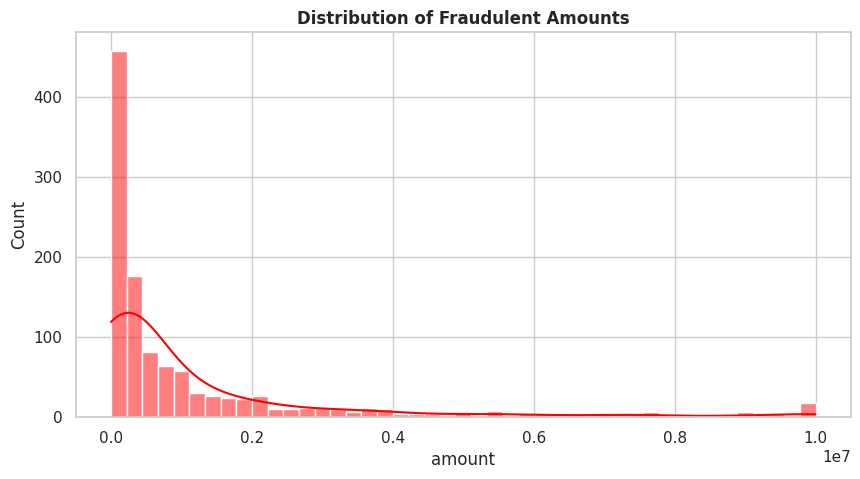

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['isFraud']==1]['amount'], color='red', kde=True)
plt.title('Distribution of Fraudulent Amounts', fontweight='bold')
plt.show()

**Chart 10: Step vs. Fraud Count**

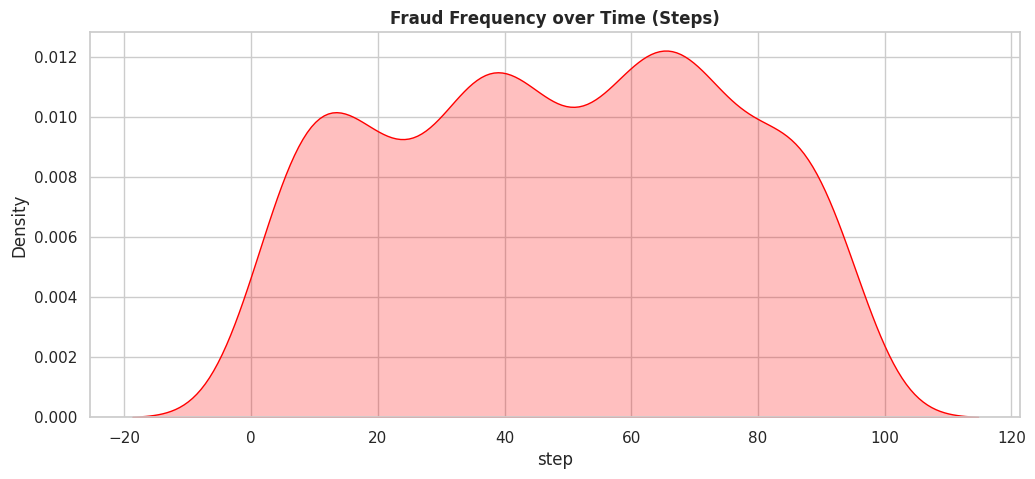

In [13]:
plt.figure(figsize=(12, 5))
sns.kdeplot(df[df['isFraud']==1]['step'], label='Fraud', shade=True, color='red')
plt.title('Fraud Frequency over Time (Steps)', fontweight='bold')
plt.show()

**Chart 11: Type vs Amount (Multivariate)**

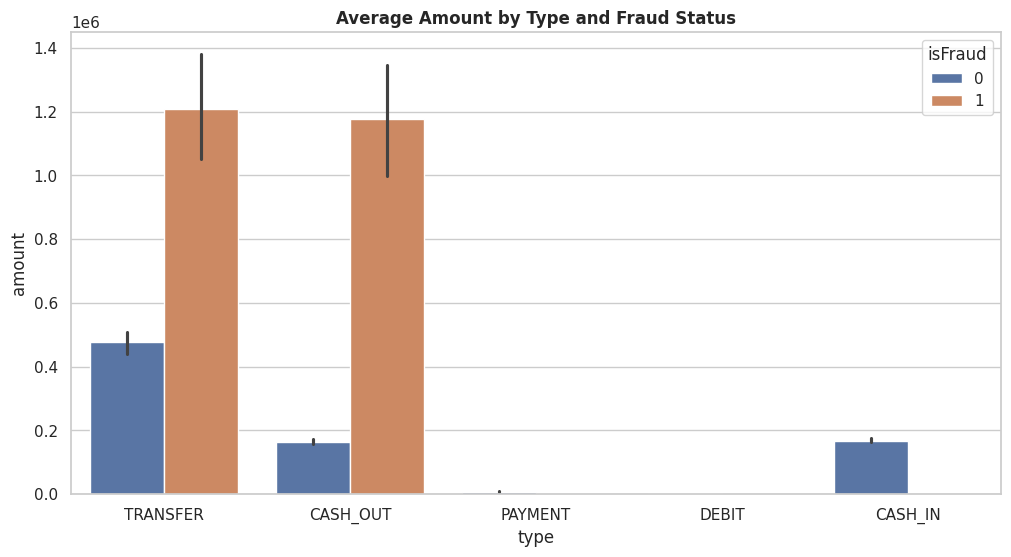

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x='type', y='amount', hue='isFraud', data=df)
plt.title('Average Amount by Type and Fraud Status', fontweight='bold')
plt.show()

##Step 5: Data Splitting and Scaling

In [15]:
# Defining Features (X) and Target (y)
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

# Splitting the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing features (Essential for Logistic Regression, KNN, and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data split and scaling completed. Ready for modeling.")

✅ Data split and scaling completed. Ready for modeling.


##Step 6: Machine Learning Modeling

**1. Logistic Regression**

Best for establishing a linear baseline for fraud detection.

--- Training Logistic Regression ---
Accuracy: 0.9861

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.87      0.93       228

    accuracy                           0.99      2229
   macro avg       0.99      0.93      0.96      2229
weighted avg       0.99      0.99      0.99      2229



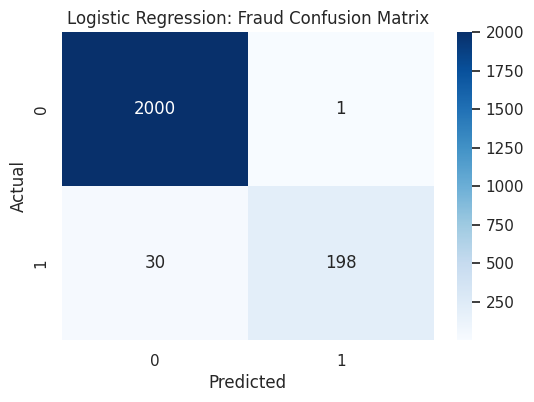

In [16]:
# Section: Logistic Regression
print("--- Training Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
lr_preds = lr_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression: Fraud Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**2. K-Nearest Neighbors (KNN)**

Detects fraud by looking at similar transaction patterns.

--- Training K-Nearest Neighbors ---
Accuracy: 0.9901

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       1.00      0.90      0.95       228

    accuracy                           0.99      2229
   macro avg       0.99      0.95      0.97      2229
weighted avg       0.99      0.99      0.99      2229



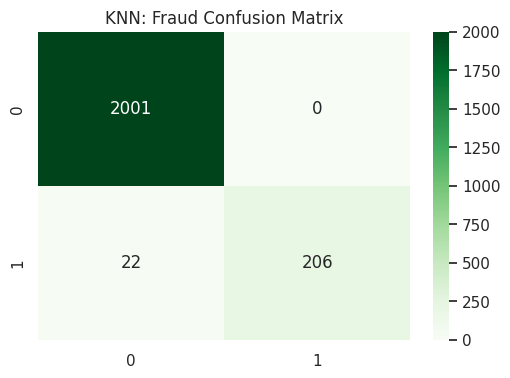

In [17]:
# Section: K-Nearest Neighbors
print("--- Training K-Nearest Neighbors ---")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
knn_preds = knn_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, knn_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, fmt='d', cmap='Greens')
plt.title('KNN: Fraud Confusion Matrix')
plt.show()

# **3. Decision Tree Classifier**

Easy to explain: asks questions about 'amount' and 'oldbalanceOrg' to find fraud.

--- Training Decision Tree ---
Accuracy: 0.9960

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.96      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



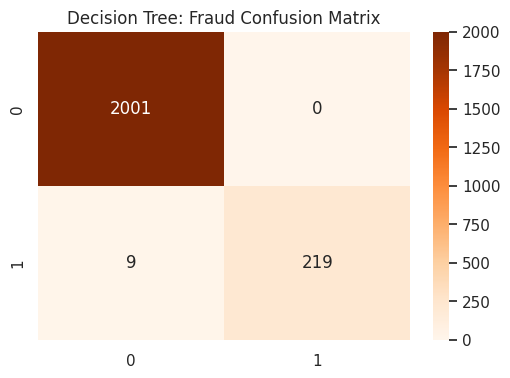

In [18]:
# Section: Decision Tree
print("--- Training Decision Tree ---")
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions and Evaluation
dt_preds = dt_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, dt_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Oranges')
plt.title('Decision Tree: Fraud Confusion Matrix')
plt.show()

**4. Random Forest Classifier**

A powerful ensemble of trees; usually very accurate for financial fraud.

--- Training Random Forest ---
Accuracy: 0.9960

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.96      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



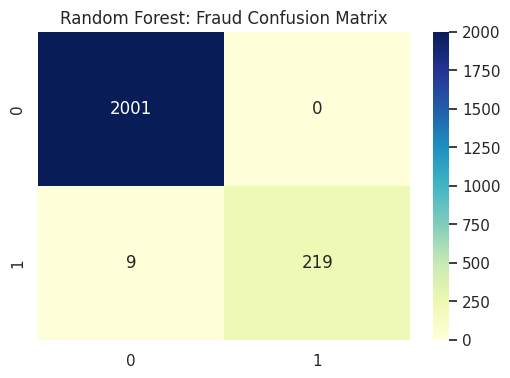

In [19]:
# Section: Random Forest
print("--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
rf_preds = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Random Forest: Fraud Confusion Matrix')
plt.show()

**5. XGBoost Classifier**

The most efficient and accurate model for high-stakes fraud detection.

--- Training XGBoost ---
Accuracy: 0.9969

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



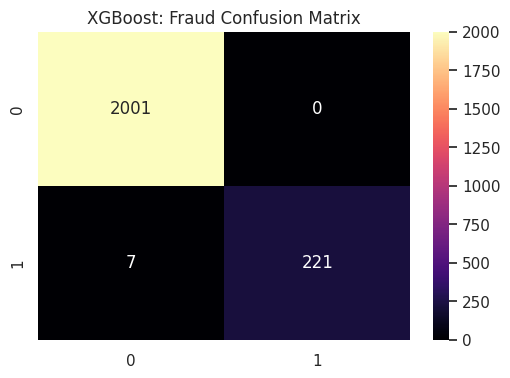

In [20]:
import xgboost as xgb

# Section: XGBoost
print("--- Training XGBoost ---")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions and Evaluation
xgb_preds = xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='magma')
plt.title('XGBoost: Fraud Confusion Matrix')
plt.show()

##Step 8: ROC AUC Curve Comparison

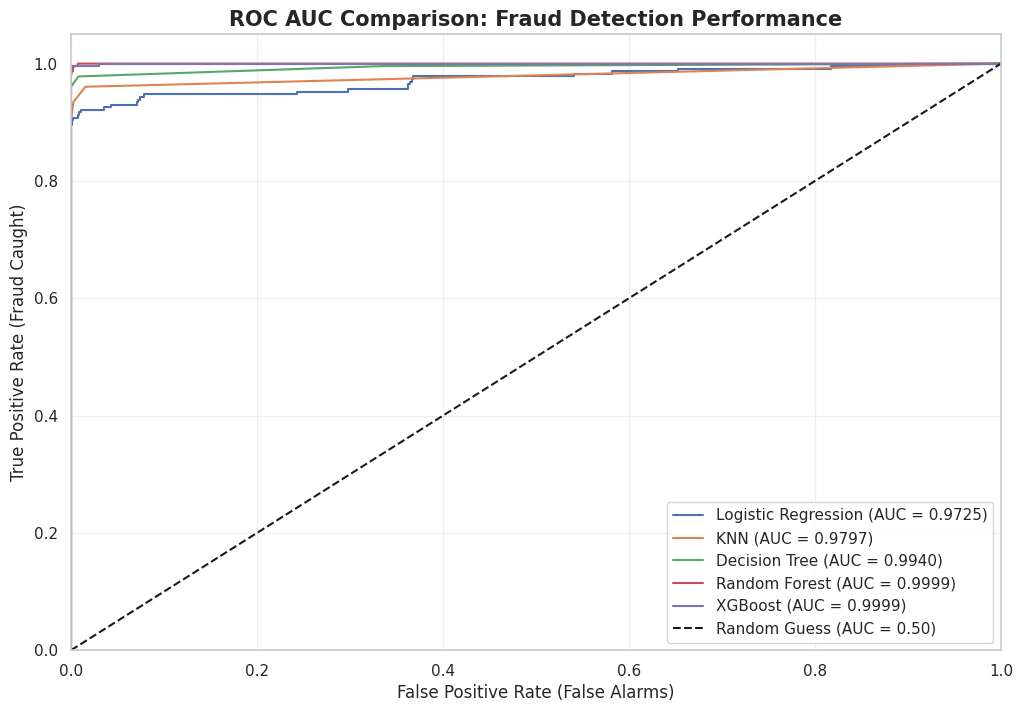

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Initialize the plot
plt.figure(figsize=(12, 8))

# Define the models and their corresponding test data (Scaled vs Unscaled)
fraud_models = [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('KNN', knn_model, X_test_scaled),
    ('Decision Tree', dt_model, X_test),
    ('Random Forest', rf_model, X_test),
    # ('Gradient Boosting', gb_model, X_test), # This line caused the error, as gb_model was not defined
    ('XGBoost', xgb_model, X_test)
]

for name, model, x_data in fraud_models:
    # Get the probability of the transaction being Fraud (Class 1)
    probs = model.predict_proba(x_data)[:, 1]

    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, probs)

    # Calculate the AUC Score
    auc_val = roc_auc_score(y_test, probs)

    # Plot the line for this model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

# Plot the diagonal 50/50 line (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Chart Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Fraud Caught)', fontsize=12)
plt.title('ROC AUC Comparison: Fraud Detection Performance', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [22]:
import joblib

# This saves the trained model to a file
joblib.dump(rf_model, 'fraud_model.pkl')

# This saves the encoder so the app understands the 'type' column
joblib.dump(le, 'label_encoder.pkl')

print("Files saved successfully!")

Files saved successfully!
